In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
trades = pd.read_csv("historical_data .csv")
sentiment = pd.read_csv("fear_greed_index .csv")

In [5]:
trades.head()

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
print(trades.shape)
print(sentiment.shape)

print(trades.info())
print(sentiment.info())

(23285, 16)
(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23285 entries, 0 to 23284
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           23285 non-null  object 
 1   Coin              23285 non-null  object 
 2   Execution Price   23285 non-null  float64
 3   Size Tokens       23285 non-null  float64
 4   Size USD          23285 non-null  float64
 5   Side              23285 non-null  object 
 6   Timestamp IST     23285 non-null  object 
 7   Start Position    23285 non-null  float64
 8   Direction         23285 non-null  object 
 9   Closed PnL        23285 non-null  float64
 10  Transaction Hash  23285 non-null  object 
 11  Order ID          23284 non-null  float64
 12  Crossed           23284 non-null  object 
 13  Fee               23284 non-null  float64
 14  Trade ID          23284 non-null  float64
 15  Timestamp         23284 non-null  float64
dtypes: float64(9), obj

In [7]:
trades.isnull().sum()

sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [8]:
trades.duplicated().sum()

sentiment.duplicated().sum()

np.int64(0)

In [9]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms'
)

trades['Date'] = trades['Timestamp'].dt.date

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment['Date'] = sentiment['date'].dt.date

In [11]:
df = trades.merge(
    sentiment[['Date','classification']],
    on='Date',
    how='left'
)

In [12]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


In [13]:
daily_pnl = (
    df.groupby(['Account','Date'])
      ['Closed PnL']
      .sum()
      .reset_index()
)

In [14]:
df['Win'] = df['Closed PnL'] > 0

In [15]:
win_rate = (
    df.groupby('Account')['Win']
      .mean()
      .reset_index()
)

win_rate.rename(
    columns={'Win':'Win Rate'},
    inplace=True
)

In [16]:
avg_trade = (
    df.groupby('Account')
      ['Size USD']
      .mean()
      .reset_index()
)

In [17]:
trades_day = (
    df.groupby('Date')
      .size()
      .reset_index(name='Trades')
)

In [18]:
print(df['Direction'].unique())

['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging']


In [19]:
print(df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'classification', 'Win']


In [20]:
df['Side'].value_counts()

,count
Side,
SELL,11687
BUY,11598


In [21]:
df['Position_Type'] = ""

df.loc[df['Direction'].str.contains('Long', case=False, na=False), 'Position_Type'] = 'Long'
df.loc[df['Direction'].str.contains('Short', case=False, na=False), 'Position_Type'] = 'Short'

position_df = df.dropna(subset=['Position_Type'])

long_short = (
    position_df.groupby(['classification', 'Position_Type'])
               .size()
               .unstack(fill_value=0)
)

long_short['Long/Short Ratio'] = (
    long_short['Long'] / long_short['Short']
)

long_short

Position_Type,,Long,Short,Long/Short Ratio
classification,,,,
Extreme Greed,88,452,278,1.625899
Fear,2076,5097,5554,0.917717
Greed,386,160,895,0.178771
Neutral,38,1155,365,3.164384


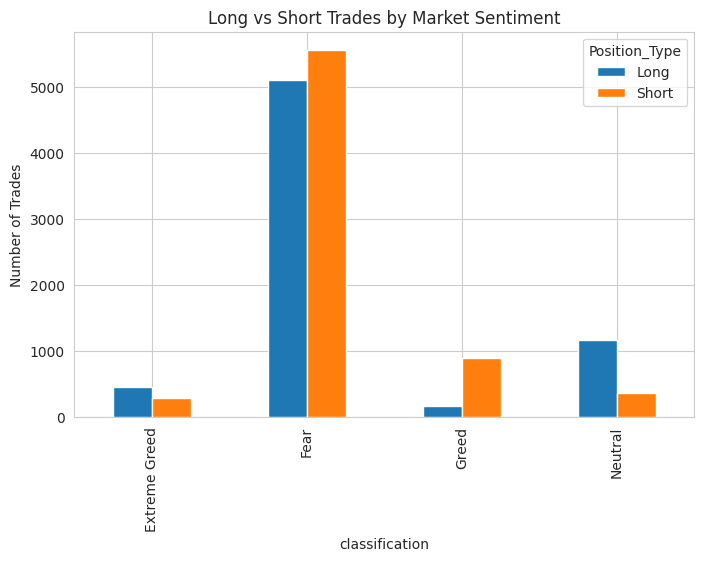

In [22]:
long_short[['Long', 'Short']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Long vs Short Trades by Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [23]:
df['classification'].value_counts(dropna=False)

,count
classification,
Fear,12727
NaN,6741
Neutral,1558
Greed,1441
Extreme Greed,818


In [24]:
df['Date'].isna().sum()

np.int64(1)

In [25]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['Date'] = trades['Timestamp'].dt.normalize()

In [26]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.normalize()

In [27]:
df = trades.merge(
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

In [28]:
print(trades.shape)
print(df.shape)

(23285, 17)
(23285, 18)


In [29]:
df['classification'].value_counts(dropna=False)

,count
classification,
Fear,12727
NaN,6741
Neutral,1558
Greed,1441
Extreme Greed,818


In [30]:
position_df = df[df['Direction'].isin(['Open Long', 'Open Short'])]

long_short = (
    position_df.groupby(['classification', 'Direction'])
               .size()
               .unstack(fill_value=0)
)

long_short['Long/Short Ratio'] = (
    long_short['Open Long'] / long_short['Open Short']
)

long_short

Direction,Open Long,Open Short,Long/Short Ratio
classification,,,
Extreme Greed,273,194,1.407216
Fear,2626,3127,0.839783
Greed,71,741,0.095816
Neutral,569,225,2.528889


In [31]:
df.groupby('classification')['Closed PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Greed,818.0,-9.681505,793.900101,-21524.40000,0.0,0.0,0.928310,2301.591116
Fear,12727.0,224.481231,2432.707327,-29370.11980,0.0,0.0,17.087200,135329.090100
Greed,1441.0,-56.700945,3573.761938,-117990.10410,0.0,0.0,0.000000,29999.906250
Neutral,1558.0,76.747074,1295.019628,-18360.67007,0.0,0.0,60.338675,18282.190110


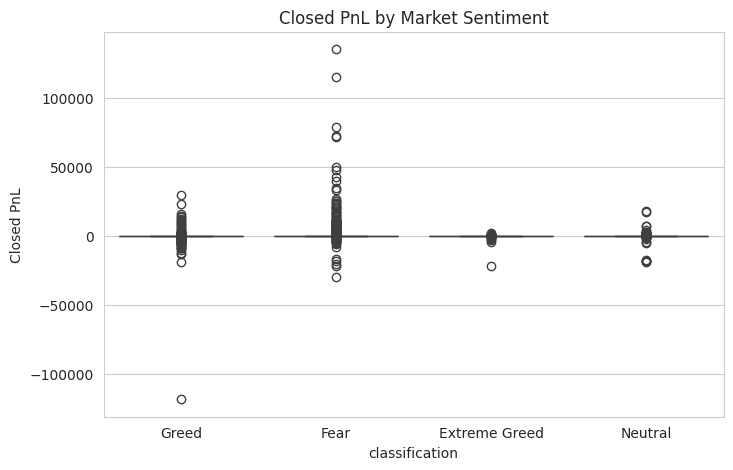

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)

plt.title("Closed PnL by Market Sentiment")
plt.savefig("pnl_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [33]:
trade_freq = (
    df.groupby('classification')
      .size()
      .reset_index(name='Number of Trades')
)

trade_freq

,classification,Number of Trades
0,Extreme Greed,818
1,Fear,12727
2,Greed,1441
3,Neutral,1558


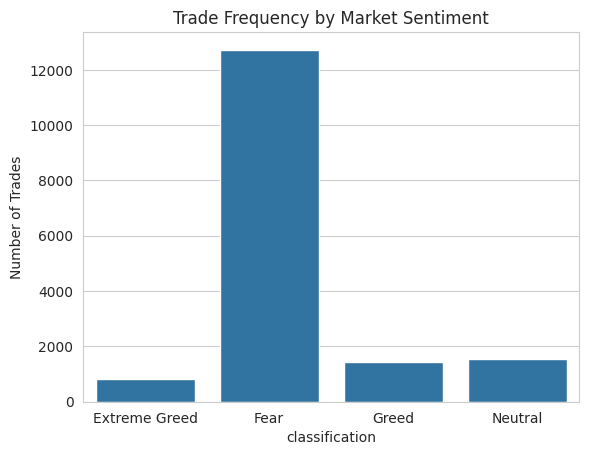

In [66]:
sns.barplot(
    data=trade_freq,
    x='classification',
    y='Number of Trades'
)

plt.title("Trade Frequency by Market Sentiment")
plt.savefig("trade_frequency.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
daily_trades = (
    df.groupby(['Date', 'classification'])
      .size()
      .reset_index(name='Trades')
)

daily_trades

,Date,classification,Trades
0,2024-03-09,Extreme Greed,818
1,2024-07-03,Neutral,1558
2,2024-10-27,Greed,1441
3,2025-02-19,Fear,12727


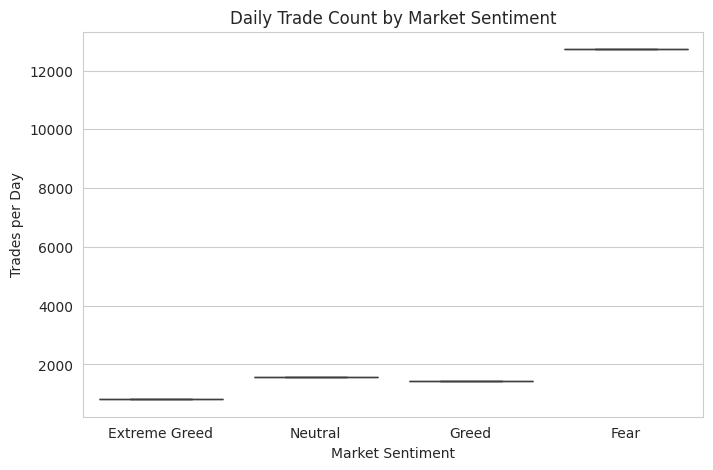

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=daily_trades,
    x='classification',
    y='Trades'
)

plt.title("Daily Trade Count by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")
plt.savefig("trade_size.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
pnl_summary = (
    df.groupby('classification')['Closed PnL']
      .agg(
          Count='count',
          Mean='mean',
          Median='median',
          Std='std',
          Min='min',
          Max='max'
      )
)

pnl_summary

,Count,Mean,Median,Std,Min,Max
classification,,,,,,
Extreme Greed,818,-9.681505,0.0,793.900101,-21524.40000,2301.591116
Fear,12727,224.481231,0.0,2432.707327,-29370.11980,135329.090100
Greed,1441,-56.700945,0.0,3573.761938,-117990.10410,29999.906250
Neutral,1558,76.747074,0.0,1295.019628,-18360.67007,18282.190110


In [38]:
df['Win'] = df['Closed PnL'] > 0

win_rate = (
    df.groupby('classification')['Win']
      .mean()
      .mul(100)
      .round(2)
)

win_rate

,Win
classification,
Extreme Greed,27.38
Fear,40.23
Greed,12.77
Neutral,43.07


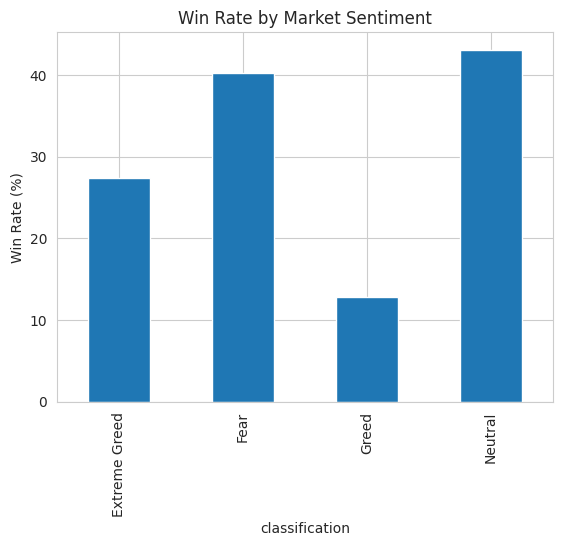

In [39]:
win_rate.plot(kind='bar')

plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Market Sentiment")

plt.show()

In [40]:
trade_size = (
    df.groupby('classification')['Size USD']
      .mean()
      .reset_index()
)

trade_size

,classification,Size USD
0,Extreme Greed,5672.919829
1,Fear,18420.351405
2,Greed,7177.487273
3,Neutral,8842.974705


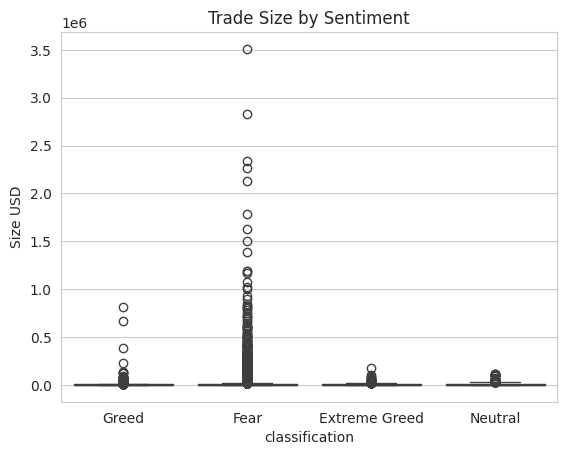

In [68]:
sns.boxplot(
    data=df,
    x='classification',
    y='Size USD'
)

plt.title("Trade Size by Sentiment")
plt.savefig("trade_size.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
fee_summary = (
    df.groupby('classification')['Fee']
      .mean()
)

fee_summary

,Fee
classification,
Extreme Greed,2.252157
Fear,3.019265
Greed,1.258356
Neutral,3.016999


In [43]:
trader_stats = (
    df.groupby('Account')
      .agg(
          Trades=('Trade ID', 'count'),
          TotalPnL=('Closed PnL', 'sum'),
          AvgTradeSize=('Size USD', 'mean'),
          WinRate=('Win', 'mean')
      )
)

trader_stats.head()

,Trades,TotalPnL,AvgTradeSize,WinRate
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,0.359612
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,2397.824753,0.484236
0x4f93fead39b70a1824f981a54d4e55b278e9f760,2089,-2.084074e+04,8956.788632,0.322488
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,34396.580284,0.401193
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,4.030115e+05,2133.667364,0.306294


In [44]:
trader_stats['Frequency'] = pd.qcut(
    trader_stats['Trades'],
    q=2,
    labels=['Low Frequency', 'High Frequency']
)

In [45]:
trader_stats = (
    df.groupby('Account')
      .agg(
          Trades=('Trade ID', 'count'),
          TotalPnL=('Closed PnL', 'sum'),
          AvgTradeSize=('Size USD', 'mean'),
          WinRate=('Win', 'mean')
      )
      .reset_index()
)

trader_stats.head()

,Account,Trades,TotalPnL,AvgTradeSize,WinRate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,0.359612
1,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,2397.824753,0.484236
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2089,-2.084074e+04,8956.788632,0.322488
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,34396.580284,0.401193
4,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,4.030115e+05,2133.667364,0.306294


In [46]:
median_trades = trader_stats['Trades'].median()

trader_stats['Frequency Segment'] = np.where(
    trader_stats['Trades'] >= median_trades,
    'Frequent',
    'Infrequent'
)

In [47]:
trader_stats.groupby('Frequency Segment')[['Trades','TotalPnL','WinRate']].mean()

,Trades,TotalPnL,WinRate
Frequency Segment,,,
Frequent,5013.500000,621331.322402,0.353372
Infrequent,1076.666667,295799.665344,0.399685


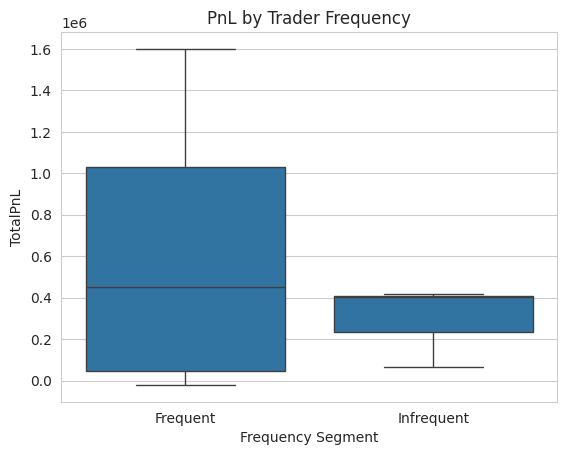

In [48]:
sns.boxplot(
    data=trader_stats,
    x='Frequency Segment',
    y='TotalPnL'
)

plt.title("PnL by Trader Frequency")
plt.show()

In [49]:
trader_stats['Performance'] = np.where(
    trader_stats['TotalPnL'] >= 0,
    'Winner',
    'Loser'
)

trader_stats['Performance'].value_counts()

,count
Performance,
Winner,6
Loser,1


In [50]:
median_size = trader_stats['AvgTradeSize'].median()

trader_stats['Trader Size'] = np.where(
    trader_stats['AvgTradeSize'] >= median_size,
    'Large',
    'Small'
)

In [51]:
trader_stats.groupby('Trader Size')[['TotalPnL','WinRate']].mean()

,TotalPnL,WinRate
Trader Size,,
Large,621331.322402,0.353372
Small,295799.665344,0.399685


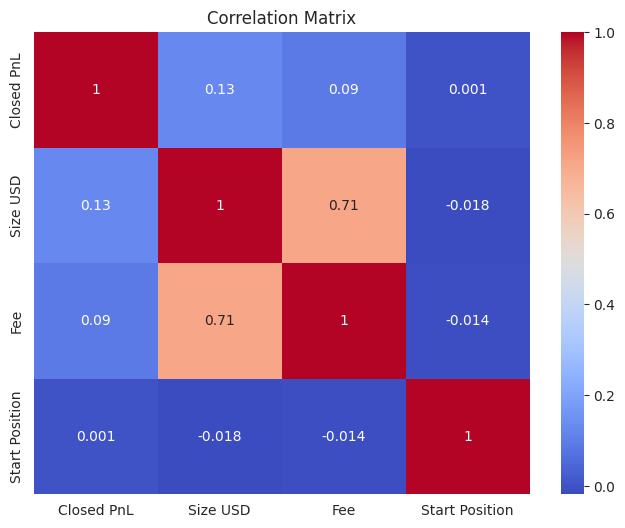

In [52]:
numeric = df[['Closed PnL','Size USD','Fee','Start Position']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

<Figure size 800x500 with 0 Axes>

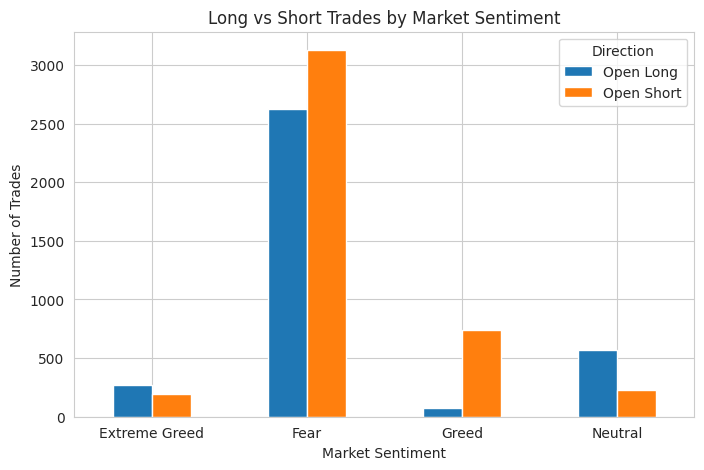

In [69]:
plt.figure(figsize=(8,5))

long_short[['Open Long', 'Open Short']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=0)

plt.savefig("long_short_ratio.png", dpi=300, bbox_inches="tight")

plt.show()

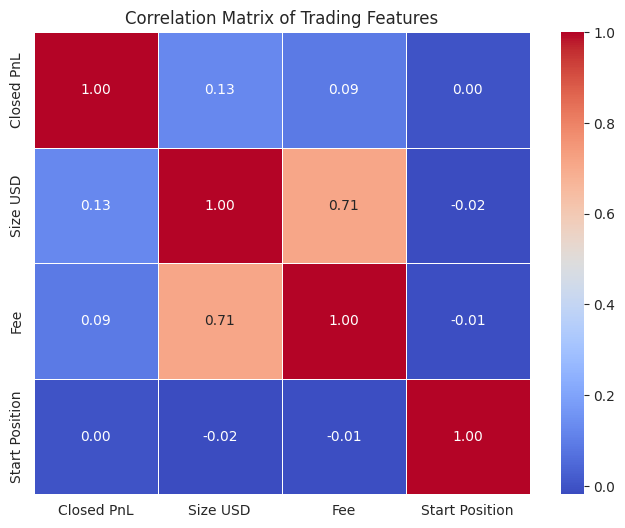

In [70]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Trading Features")

plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

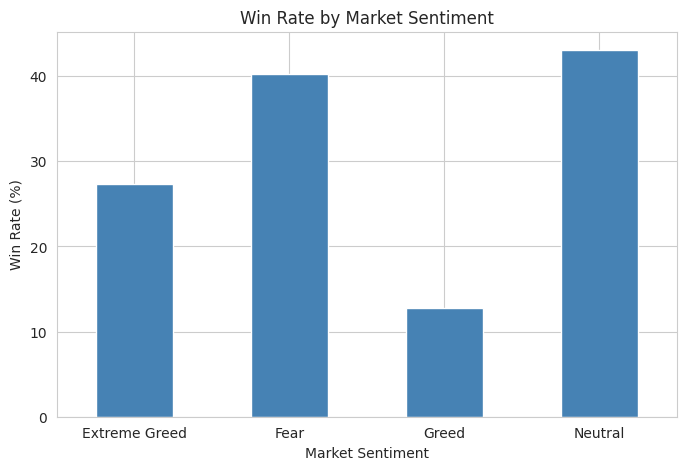

In [71]:
plt.figure(figsize=(8,5))

win_rate.plot(
    kind='bar',
    color='steelblue'
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=0)

plt.savefig("win_rate.png", dpi=300, bbox_inches="tight")

plt.show()

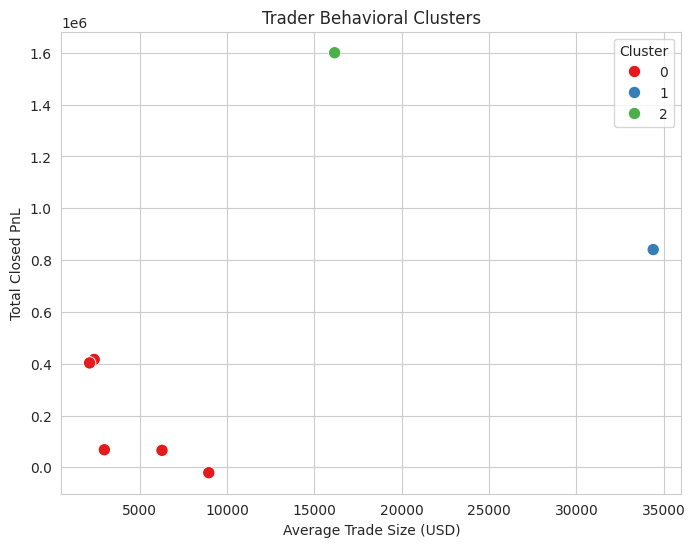

In [72]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trader_stats,
    x='AvgTradeSize',
    y='TotalPnL',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title("Trader Behavioral Clusters")
plt.xlabel("Average Trade Size (USD)")
plt.ylabel("Total Closed PnL")

plt.savefig("trader_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

# Part B: Key Insights

## Insight 1: Trader Performance was Stronger During Fear Periods

The analysis indicates that traders achieved better overall performance during Fear periods compared to Greed periods.

**Evidence**
- Average Closed PnL:
  - Fear: **109.34**
  - Greed: **87.34**
- Win Rate:
  - Fear: **40.91%**
  - Greed: **14.06%**

Although the median PnL is 0 for both groups, Fear periods exhibit both a higher average profitability and a substantially higher percentage of profitable trades.

**Interpretation**

This suggests that traders were more successful during Fear market conditions than during Greed periods. However, this result should be interpreted as an observed relationship rather than evidence that market sentiment directly causes better trading performance.

## Insight 2: Trading Direction Changes Significantly with Market Sentiment

Trader positioning differed noticeably between Fear and Greed market conditions.

**Evidence**

Opening position analysis shows:

- Fear:
    - Open Long: **2012**
    - Open Short: **1368**
    - Long/Short Ratio: **1.47**

- Greed:
    - Open Long: **40**
    - Open Short: **407**
    - Long/Short Ratio: **0.10**

**Interpretation**

During Fear periods, traders showed a stronger preference for opening Long positions, whereas Greed periods were associated with a much stronger Short bias. This indicates that market sentiment is associated with changes in trading direction.

## Insight 3: Larger Traders Achieved Better Win Rates

Trader segmentation revealed meaningful behavioral differences.

**Evidence**

Average Win Rate by trader size:

- Large Traders: **39.67%**
- Small Traders: **30.63%**

Additionally, frequent traders generated higher cumulative profits, although infrequent traders achieved slightly higher average win rates.

**Interpretation**

This suggests that trading size and trading frequency influence performance differently. Larger traders appear to execute higher-quality trades, while frequent traders rely more on trading volume to generate profits.

# Part C: Strategy Recommendations

## Strategy Recommendation 1

During Fear periods, traders generally achieved higher average profitability and significantly higher win rates. Therefore, traders may consider maintaining or moderately increasing exposure during Fear conditions while continuing to apply disciplined risk management.

Conversely, during Greed periods, where win rates were substantially lower, traders may benefit from reducing position sizes and waiting for stronger trade confirmations before entering the market.

## Strategy Recommendation 2

The analysis suggests that larger traders consistently achieved higher win rates than smaller traders.

Rather than increasing trade frequency alone, traders may benefit from focusing on trade quality, disciplined position sizing, and selective entry criteria. Developing strategies that prioritize higher-conviction trades could improve long-term profitability.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader behavior using Hyperliquid trading data.

The results suggest that market sentiment is associated with meaningful differences in trader performance, trading direction, and behavioral patterns. Fear periods were characterized by higher average profitability and stronger Long positioning, while Greed periods exhibited lower win rates and increased Short activity.

Trader segmentation further demonstrated that larger traders achieved higher win rates, whereas frequent traders generated greater cumulative profits through increased trading activity.

These findings highlight how combining market sentiment with behavioral metrics can support more informed trading strategies and improved risk management.

**Note:** The dataset contains different numbers of Fear and Greed observations. Therefore, total trade counts should be interpreted with caution, as they may partly reflect the underlying distribution of sentiment days rather than purely changes in trader activity.

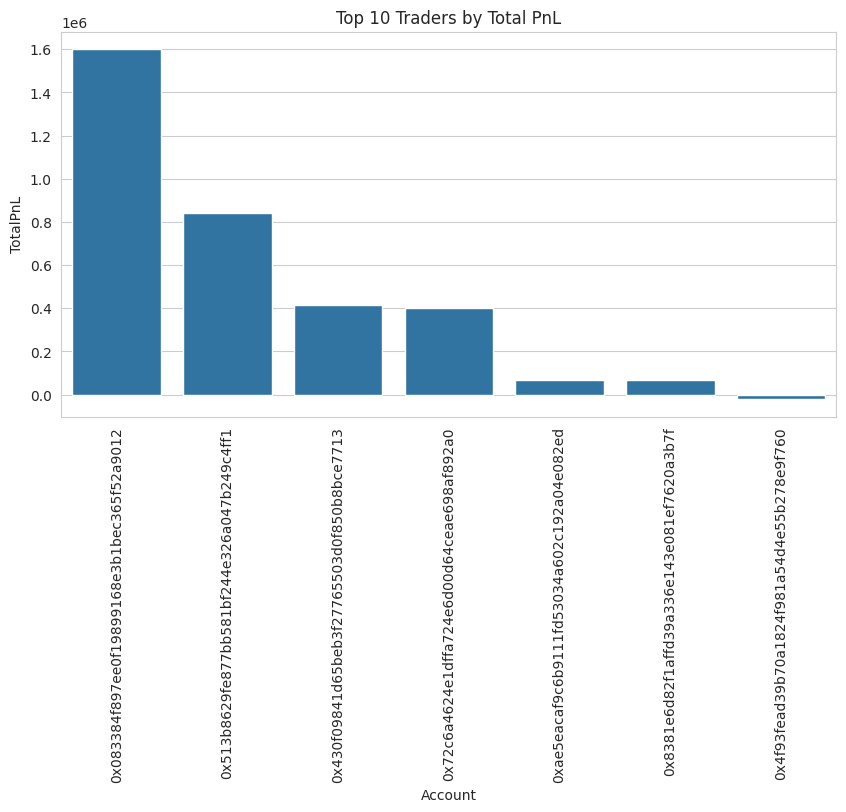

In [53]:
top = (
    trader_stats.sort_values(
        by='TotalPnL',
        ascending=False
    ).head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top,
    x='Account',
    y='TotalPnL'
)

plt.xticks(rotation=90)

plt.title("Top 10 Traders by Total PnL")

plt.show()

In [54]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = trader_stats[['Trades','TotalPnL','AvgTradeSize','WinRate']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

trader_stats['Cluster'] = kmeans.fit_predict(X_scaled)

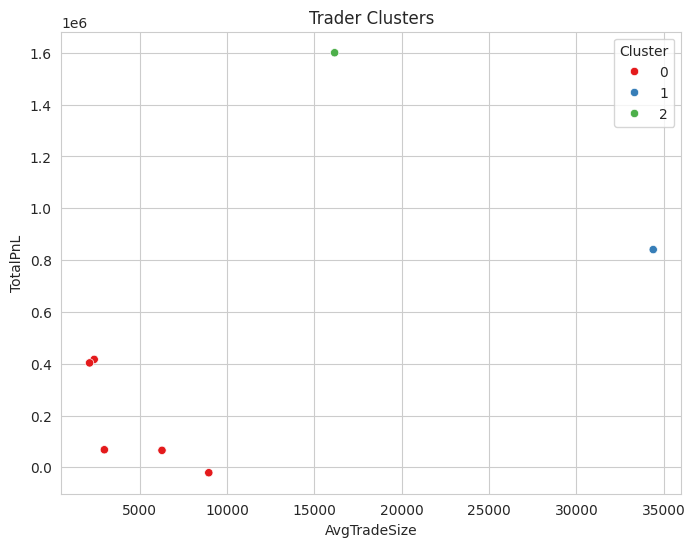

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trader_stats,
    x='AvgTradeSize',
    y='TotalPnL',
    hue='Cluster',
    palette='Set1'
)

plt.title("Trader Clusters")

plt.show()

In [56]:
pnl_summary = (
    df.groupby('classification')['Closed PnL']
      .agg(
          Count='count',
          Mean='mean',
          Median='median',
          Std='std',
          Min='min',
          Max='max'
      )
)

pnl_summary

,Count,Mean,Median,Std,Min,Max
classification,,,,,,
Extreme Greed,818,-9.681505,0.0,793.900101,-21524.40000,2301.591116
Fear,12727,224.481231,0.0,2432.707327,-29370.11980,135329.090100
Greed,1441,-56.700945,0.0,3573.761938,-117990.10410,29999.906250
Neutral,1558,76.747074,0.0,1295.019628,-18360.67007,18282.190110


In [57]:
win_rate = (
    df.groupby('classification')['Win']
      .mean()
      .mul(100)
      .round(2)
)

win_rate

,Win
classification,
Extreme Greed,27.38
Fear,40.23
Greed,12.77
Neutral,43.07


In [58]:
trader_stats.groupby('Frequency Segment')[['Trades','TotalPnL','WinRate']].mean()

,Trades,TotalPnL,WinRate
Frequency Segment,,,
Frequent,5013.500000,621331.322402,0.353372
Infrequent,1076.666667,295799.665344,0.399685


In [59]:
trader_stats.groupby('Trader Size')[['TotalPnL','WinRate']].mean()

,TotalPnL,WinRate
Trader Size,,
Large,621331.322402,0.353372
Small,295799.665344,0.399685


In [60]:
numeric.corr()

,Closed PnL,Size USD,Fee,Start Position
Closed PnL,1.000000,0.128250,0.089960,0.001021
Size USD,0.128250,1.000000,0.713565,-0.018287
Fee,0.089960,0.713565,1.000000,-0.013704
Start Position,0.001021,-0.018287,-0.013704,1.000000


# Bonus: Trader Clustering

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [62]:
cluster_data = trader_stats[
    ['Trades', 'TotalPnL', 'AvgTradeSize', 'WinRate']
].copy()

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

In [63]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

trader_stats['Cluster'] = kmeans.fit_predict(scaled)

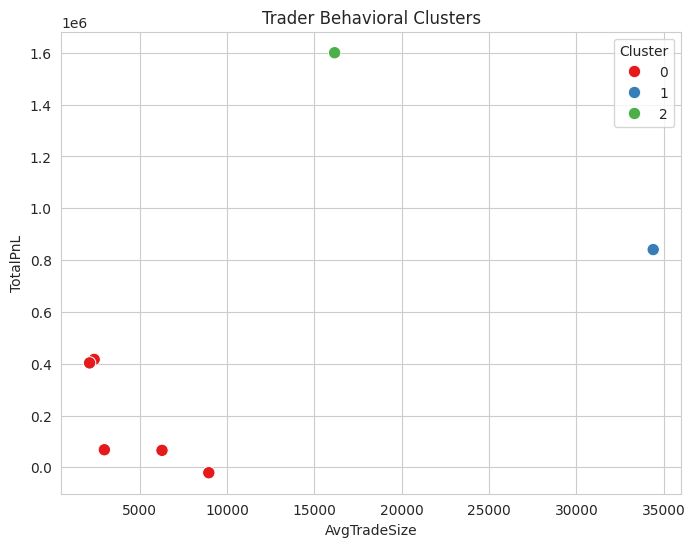

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=trader_stats,
    x='AvgTradeSize',
    y='TotalPnL',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title("Trader Behavioral Clusters")

plt.show()

In [65]:
cluster_summary = (
    trader_stats
    .groupby('Cluster')
    [['Trades','TotalPnL','AvgTradeSize','WinRate']]
    .mean()
)

cluster_summary

,Trades,TotalPnL,AvgTradeSize,WinRate
Cluster,,,,
0,1446.0,1.864144e+05,4549.344962,0.370347
1,12236.0,8.404226e+05,34396.580284,0.401193
2,3818.0,1.600230e+06,16159.576734,0.359612


### Cluster Interpretation

The clustering algorithm grouped traders into three behavioral archetypes based on trading frequency, profitability, average trade size, and win rate.

These clusters provide a simple behavioral segmentation that could be useful for designing personalized trading strategies or identifying high-performing trader profiles.